# Rental Pricing Prediction: Data Exploration & Baseline Model
---
**Objective:** Build a predictive model to estimate monthly rental prices (`rent_eur_month`) based on property features.

## 1. Environment Setup & Data Loading


In [35]:
import os
import math
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler





GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
os.environ["PYTHONHASHSEED"] = str(GLOBAL_SEED)

df_train = pd.read_csv("track_a_rental_pricing_train.csv")
df_test = pd.read_csv("track_a_rental_pricing_test.csv")

X_train = df_train.drop(columns=["rent_eur_month"])
Y_train = df_train["rent_eur_month"]

X_test = df_test.drop(columns=["rent_eur_month"])
Y_test = df_test["rent_eur_month"]

## 2. Exploratory Data Analysis (EDA)
### 2.1.0 Separating the Features
**We observe** that our dataset contains 12 distinct features of mixed data types (binary features, bounded integers, and continuous scales). Treating them the same way might lead us to wrong conclusions, hence, we will analyze them separately.

*Note: While `distance_supermarket_m` is technically represented as an integer, we will treat is as a continuous variable due to its high range*

**Thus, we partition our features into three distinct groups:**

In [ ]:
CONTINUOUS = ['surface_m2', 'building_age_years', 'distance_metro_km',
              'district_prestige_score', 'construction_quality_score', 'distance_supermarket_m']

DISCRETE   = ['num_rooms', 'floor_number', 'energy_rating',
              'num_photos']

BINARY     = ['has_elevator', 'has_parking']

#### 2.1.1 Correlation Matrix of Continuous Features

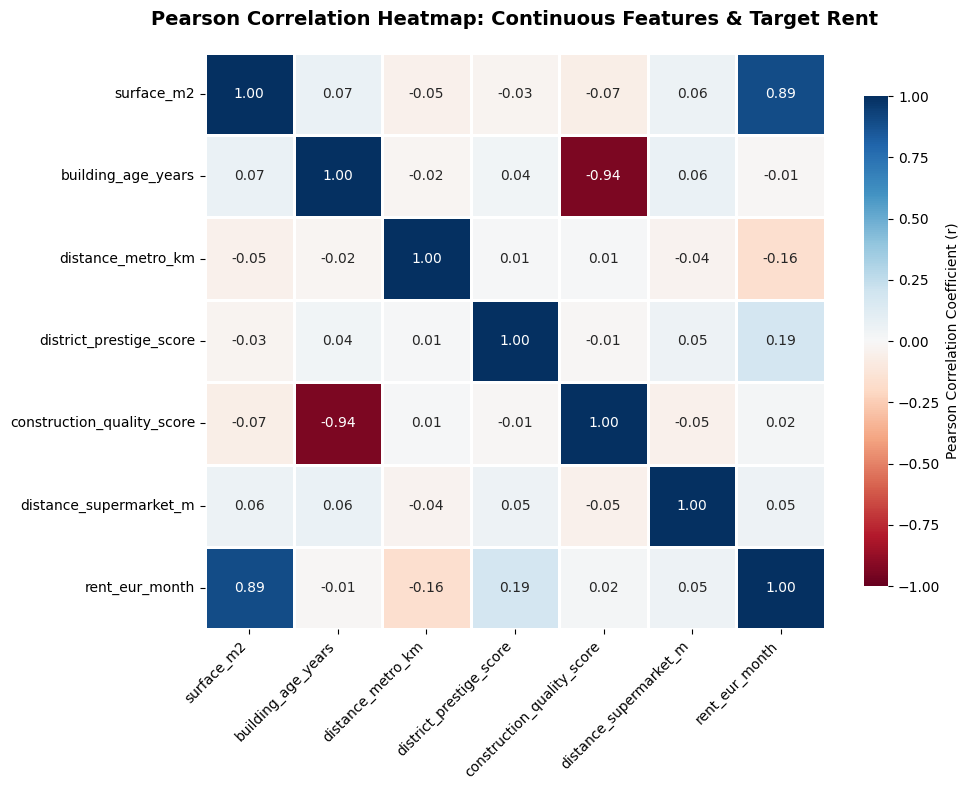

In [8]:
# 2. Extract only continuous variables + the rent target column
df_continuous = df_train[CONTINUOUS + ["rent_eur_month"]]

# 3. Calculate the standard Pearson correlation matrix
continuous_corr = df_continuous.corr(method="pearson")

# 4. Set up the plotting environment
plt.figure(figsize=(10, 8))

# 5. Generate a full symmetric matrix heatmap
sns.heatmap(
    continuous_corr,
    annot=True,  # Displays the numeric correlation coefficient inside each cell
    cmap="RdBu",  # Red-to-Blue diverging color palette (Red=Negative, Blue=Positive)
    fmt=".2f",  # Limit numeric text to 2 decimal places
    vmin=-1,
    vmax=1,  # Keeps standard correlation bounds locked on the color scale
    linewidths=0.75,  # Creates a crisp border grid between matrix tiles
    cbar_kws={"shrink": 0.85, "label": "Pearson Correlation Coefficient (r)"},
)

# 6. Final Polish
plt.title(
    "Pearson Correlation Heatmap: Continuous Features & Target Rent",
    fontsize=14,
    pad=20,
    weight="bold",
)
plt.xticks(rotation=45, ha="right")  # Cleanly tilts labels to prevent overlapping
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

##### Interpretation

We observe that the rent is strongly positively correlated with the surface area, which indicates that square footage is the main factor on rental prices. 

Additionally, building age is strongly negatively correlated with the construction quality score. This implies that older buildings generally have lower quality compared to the newer ones.

Overall, we see that every other features holds minor to moderate impact on the rental prices.

#### 2.1.2 Correlation of Discrete Features

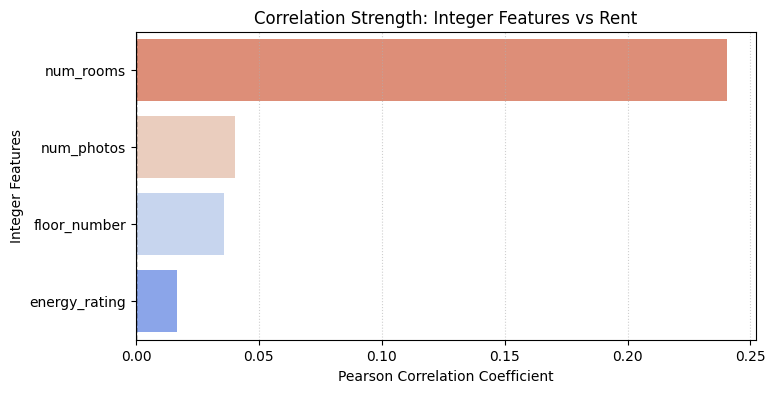

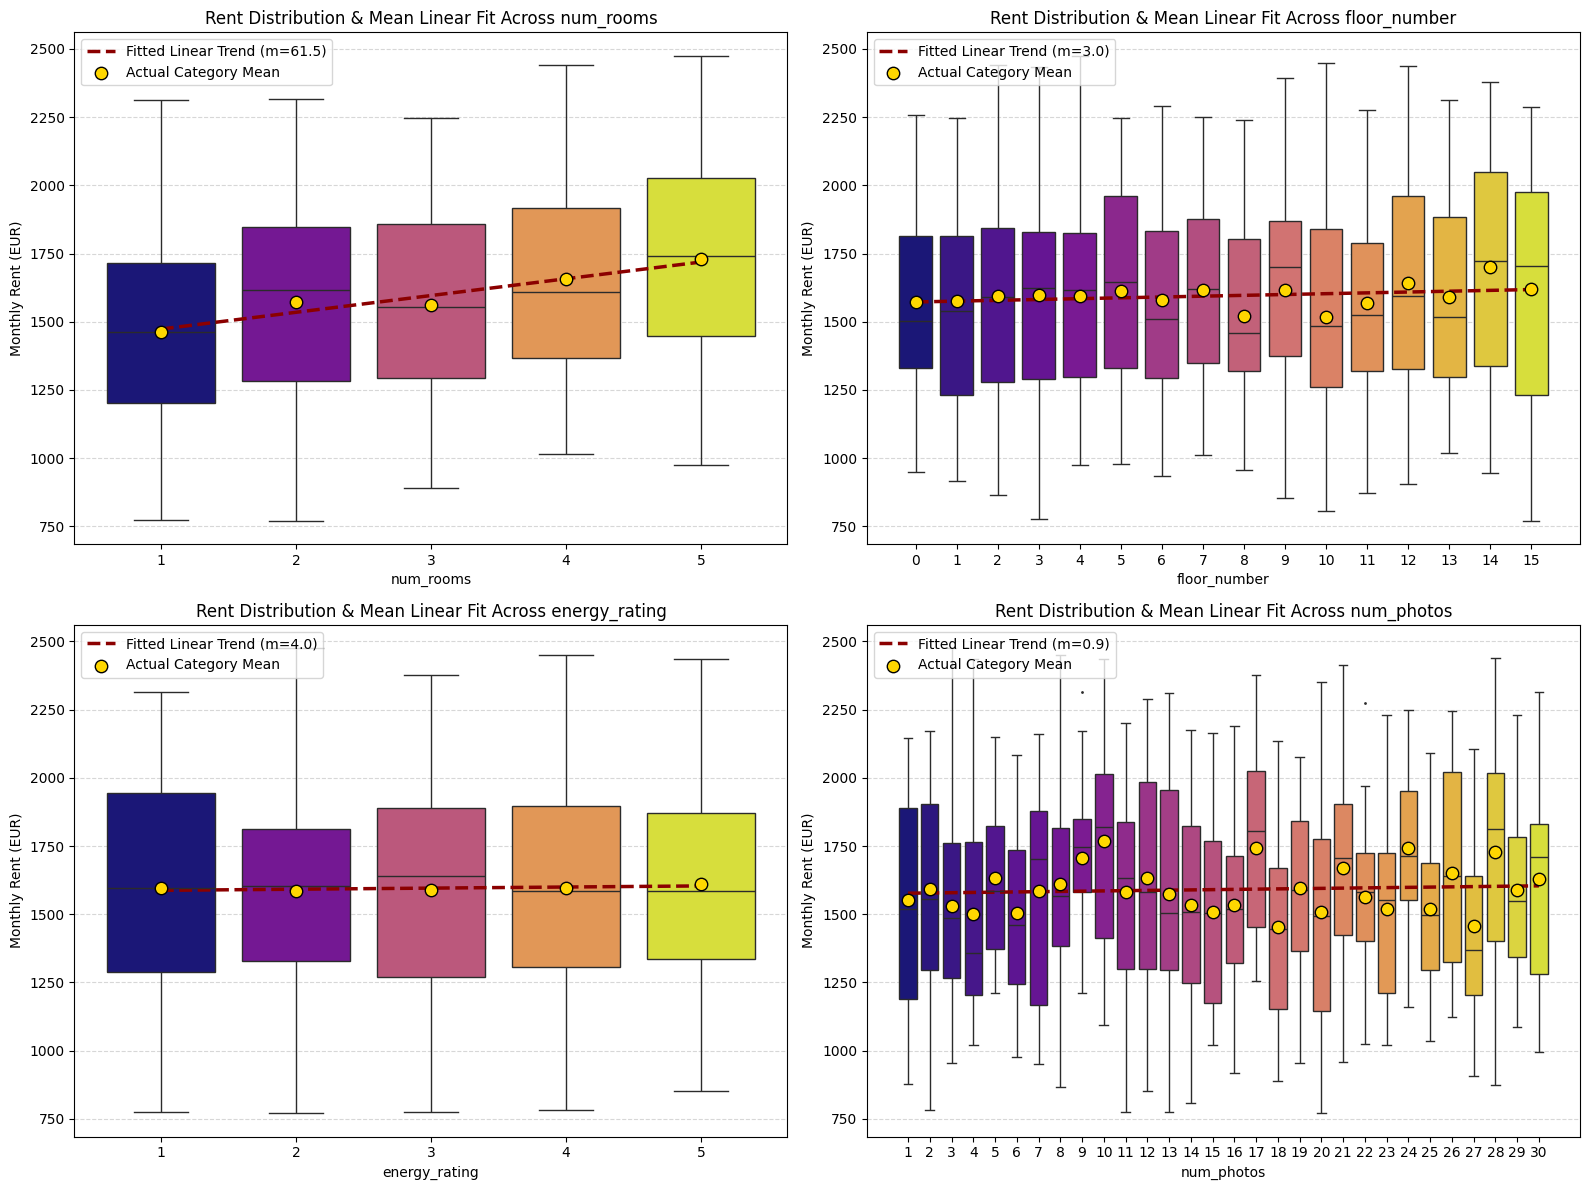

In [21]:
# 2. Calculate correlation specifically for these integer columns against rent
integer_corr = (
    df_train[DISCRETE + ["rent_eur_month"]]
    .corr(method="pearson")["rent_eur_month"]
    .drop("rent_eur_month")
    .sort_values(ascending=False)
)

# 3. Plot the Correlation Ranking
plt.figure(figsize=(8, 4))
sns.barplot(
    x=integer_corr.values, y=integer_corr.index, hue=integer_corr.index, palette="coolwarm_r", orient="h"
)
plt.axvline(x=0, color="black", linestyle="--", linewidth=1)
plt.title("Correlation Strength: Integer Features vs Rent")
plt.xlabel("Pearson Correlation Coefficient")
plt.ylabel("Integer Features")
plt.grid(axis="x", linestyle=":", alpha=0.6)
plt.show()

# 4. Generate Box Plots for key structural integer steps to inspect variance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(DISCRETE):
    # Calculate the mean rent for each discrete step and sort by index
    group_means = df_train.groupby(col)["rent_eur_month"].mean().sort_index()
    
    # Draw the baseline boxplot
    sns.boxplot(
        data=df_train,
        x=col,
        y="rent_eur_month",
        hue=col,
        ax=axes[idx],
        palette="plasma",
        legend=False,
        fliersize=1,  # Keep outlier dots tiny
    )
    
    # --- CALCULATE & FIT A LINEAR REGRESSION LINE ---
    x_indices = np.arange(len(group_means))
    y_means = group_means.values
    
    # Fit a 1st-degree polynomial (straight line)
    slope, intercept = np.polyfit(x_indices, y_means, 1)
    fitted_linear_y = slope * x_indices + intercept
    
    # Plot the true linear line of best fit
    axes[idx].plot(
        x_indices, 
        fitted_linear_y, 
        color="darkred",        
        linestyle="--",        
        linewidth=2.5,         
        label=f"Fitted Linear Trend (m={slope:.1f})"
    )
    
    # Plot the actual mean center points (Fixed zorder here 🥇)
    axes[idx].scatter(
        x_indices,
        y_means,
        color="gold",
        s=80,
        edgecolor="black",
        zorder=5,               # Fixed: changed zIndex to zorder
        label="Actual Category Mean"
    )
    
    # Configure titles, labels, and individual legends
    axes[idx].set_title(f"Rent Distribution & Mean Linear Fit Across {col}")
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel("Monthly Rent (EUR)")
    axes[idx].grid(axis="y", linestyle="--", alpha=0.5)
    axes[idx].legend(loc="upper left")

plt.tight_layout()
plt.show()

##### Interpretation

We can observe that the number of rooms has the highest correlation with rental prices. This shows that number of rooms has the biggest influence on the rent, compared to the rest of the discrete features. 

Specifically, we can discern that the rest of the discrete features have a really minimal correlation, suggesting that the rent does not truly depend neither on the number of photos nor floor number nor energy rating.

#### 2.1.3 Correlation of Binary Features

--- Absolute Premium for has_elevator ---
Mean Rent without: €1596.46
Mean Rent with:    €1594.79
Net Price Increase: +€-1.67

--- Absolute Premium for has_parking ---
Mean Rent without: €1557.88
Mean Rent with:    €1666.60
Net Price Increase: +€108.72



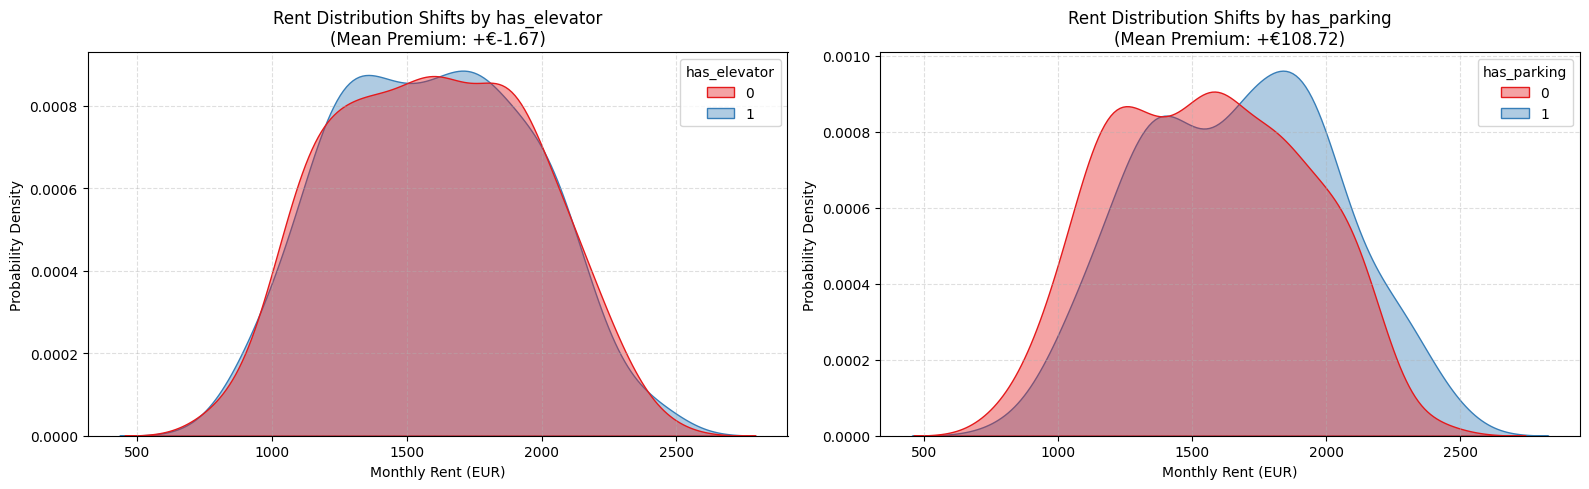

In [22]:
# 2. Render Overlapping Density Plots to inspect structural price premiums
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, col in enumerate(BINARY):
    # Calculate quantitative pricing means to find the true premium
    group_means = df_train.groupby(col)["rent_eur_month"].mean()
    
    # Premium = Mean Rent with amenity (1) minus Mean Rent without amenity (0)
    premium = group_means.loc[1] - group_means.loc[0]
    
    print(f"--- Absolute Premium for {col} ---")
    print(f"Mean Rent without: €{group_means.loc[0]:.2f}")
    print(f"Mean Rent with:    €{group_means.loc[1]:.2f}")
    print(f"Net Price Increase: +€{premium:.2f}\n")

    # Generate the KDE distribution plots
    sns.kdeplot(
        data=df_train,
        x="rent_eur_month",
        hue=col,
        fill=True,
        common_norm=False,
        palette="Set1",
        alpha=0.4,
        ax=axes[idx],
    )
    
    # Visual Polish
    axes[idx].set_title(
        f"Rent Distribution Shifts by {col}\n(Mean Premium: +€{premium:.2f})"
    )
    axes[idx].set_xlabel("Monthly Rent (EUR)")
    axes[idx].set_ylabel("Probability Density")
    axes[idx].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

##### Interpretation

We can observe that elevator has no significant value for the rental prices as both price distribution are perfectly normal and lie on top of each other.

However, parking has a noticable affect as it makes the graph left-skewed, implying that parking decently increases the price of the rent.

### 2.2 Surface Area against Rent

After examining all of the features, we can discern that the surface area is the most dominant predictor.

Let us inspect the relationship between rent and the surface.

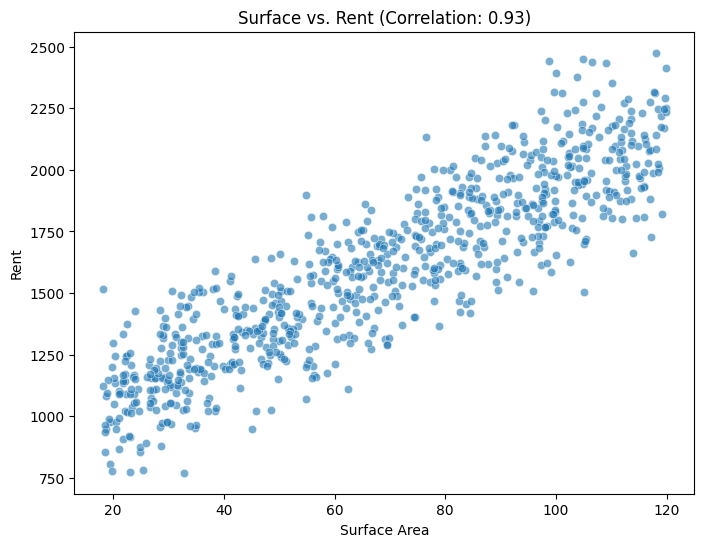

In [23]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_train, x="surface_m2", y="rent_eur_month", alpha=0.6)
plt.title("Surface vs. Rent (Correlation: 0.93)")
plt.xlabel("Surface Area")
plt.ylabel("Rent")
plt.show()

#### Interpretation

We can see an obvious linear relationship between rent and the surface area with no extreme outliers.

Thus, it suggests us to build a Linear Regression model as our evaluation baseline model.

## 3. Baseline Model 
We will fit a standard OLS Linear Regression on the training dataset and evaluate it using $R^2$, Mean Squared Error (MSE), and Root Mean Squared Error (RMSE).

In [27]:
baseline_model = LinearRegression()
baseline_model.fit(X_train, Y_train)

Y_pred_train = baseline_model.predict(X_train)
Y_pred_test = baseline_model.predict(X_test)

mse_train = mean_squared_error(Y_train, Y_pred_train)
mse_test = mean_squared_error(Y_test, Y_pred_test)

print("--- Baseline Linear Regression Performance ---")
print(f"Training R-squared: {r2_score(Y_train, Y_pred_train):.4f}")
print(f"Testing R-squared:  {r2_score(Y_test, Y_pred_test):.4f}")
print("-" * 40)
print(f"Training MSE:       {mse_train:.2f}")
print(f"Testing MSE:        {mse_test:.2f}")
print("-" * 40)
print(f"Training RMSE:      €{np.sqrt(mse_train):.2f}")
print(f"Testing RMSE:       €{np.sqrt(mse_test):.2f}")

--- Baseline Linear Regression Performance ---
Training R-squared: 0.9262
Testing R-squared:  0.9389
----------------------------------------
Training MSE:       9707.05
Testing MSE:        8800.02
----------------------------------------
Training RMSE:      €98.52
Testing RMSE:       €93.81


#### Interpretation
We can already see that the Linear Regression model has an incredible accuracy.

Let us try and observe if we can improve it furhter.

## 3.1. Residual Analysis

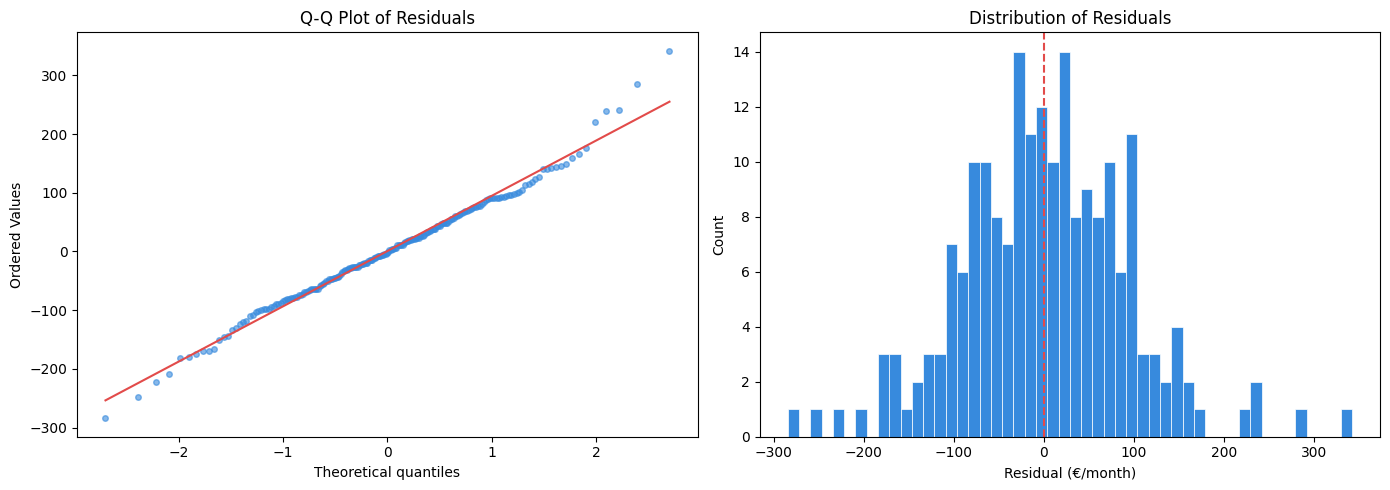

In [ ]:
residuals = (Y_test - Y_pred_test).reset_index(drop=True)

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Q-Q Plot of Residuals
stats.probplot(residuals, dist='norm', plot=axes[0])
axes[0].get_lines()[0].set(
    color='#378ADD',
    markersize=4,
    alpha=0.6
)
axes[0].get_lines()[1].set(
    color='#E24B4A',
    linewidth=1.5
)
axes[0].set_title('Q-Q Plot of Residuals')

# 2. Distribution of Residuals (Histogram)
axes[1].hist(
    residuals,
    bins=50,
    color='#378ADD',
    edgecolor='white',
    linewidth=0.5
)
axes[1].axvline(0, color='#E24B4A', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Residual (€/month)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

#### Interpretation

We can discern that the residuals follow a normal distribution with heavy tails.



In [37]:
# 2. Setup the exact same preprocessor
categorical_features = ["num_rooms", "energy_rating"]
numeric_features = [col for col in df_train.columns if col not in categorical_features + ["rent_eur_month"]]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_features),
    ]
)

# ---------------------------------------------------------
# 3. SIMPLIFIED INFLUENCE FILTERING (Cook's Distance Math)
# ---------------------------------------------------------
# Transform the training data to calculate distances matrix-style
X_trans = preprocessor.fit_transform(df_train.drop(columns=["rent_eur_month"]))
if hasattr(X_trans, "toarray"): 
    X_trans = X_trans.toarray()
X_design = np.column_stack([np.ones(X_trans.shape[0]), X_trans]) # Add intercept
Y_vals = df_train["rent_eur_month"].values

# Quick baseline fit to find the distance metrics
beta = np.linalg.lstsq(X_design, Y_vals, rcond=None)[0]
predictions = X_design @ beta
residuals = Y_vals - predictions
mse = np.sum(residuals**2) / (X_design.shape[0] - X_design.shape[1])

# Leverage (H matrix diagonal)
leverage = np.sum(X_design * (X_design @ np.linalg.pinv(X_design.T @ X_design)), axis=1)

# Cook's Distance math formula: (e^2 / p*MSE) * (h / (1-h)^2)
p = X_design.shape[1]
cooks_d = (residuals**2 / (p * mse)) * (leverage / (1 - leverage)**2)

# Filter rows below standard threshold (4 / n)
clean_mask = cooks_d < (4 / len(df_train))
df_train_clean = df_train[clean_mask]

print(f"Original Training Rows: {len(df_train)}")
print(f"Cleaned Training Rows:  {len(df_train_clean)}")
print(f"Removed {len(df_train) - len(df_train_clean)} multi-variable relationship outliers.\n")

# ---------------------------------------------------------
# 4. FINAL CLEAN PIPELINE RUN
# ---------------------------------------------------------
X_train_clean = df_train_clean.drop(columns=["rent_eur_month"])
Y_train_clean = df_train_clean["rent_eur_month"]
X_test = df_test.drop(columns=["rent_eur_month"])
Y_test = df_test["rent_eur_month"]

model_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor), ("regressor", LinearRegression())]
)
model_pipeline.fit(X_train_clean, Y_train_clean)

# Evaluate
Y_pred = model_pipeline.predict(X_test)
print(f"New Test R² Score: {r2_score(Y_test, Y_pred):.4f} (Previous Baseline: 0.9380)")

Original Training Rows: 800
Cleaned Training Rows:  760
Removed 40 multi-variable relationship outliers.

New Test R² Score: 0.9399 (Previous Baseline: 0.9380)
